# Vegetation metrics

In [114]:
import rioxarray as rxr
import xarray as xr
import numpy as np
import pandas as pd

In [117]:
# load files and combine 

years = np.arange(2014, 2026)

arrays = []

for year in years:
    da = rxr.open_rasterio(f'output-data/EVI/reprojected_EVI_{year}.tif').squeeze()
    da = da.assign_coords(year=year)
    arrays.append(da)

stack = xr.concat(arrays, dim='year')

In [118]:
stack_pixels = stack.stack(pixel=("y", "x"))

In [172]:
df = stack_pixels.transpose("pixel", "year").to_pandas()

In [173]:
# add pre-fire and post-fire EVI + study area
pre_fire = rxr.open_rasterio('output-data/predictor-layers/evi_2year_pre.tif').squeeze()
# pre_fire = rxr.open_rasterio('output-data/predictor-layers/evi_3month_pre.tif').squeeze()
post_fire = rxr.open_rasterio('output-data/predictor-layers/post_fire_evi.tif').squeeze()

study_area = rxr.open_rasterio('output-data/study-area/study_area_kalimantan.tif').squeeze()

merged = xr.merge([pre_fire.rename('pre'), 
                   post_fire.rename('post'),
                   study_area.rename('study_area')], 
                  compat='no_conflicts')

# add to df
new_cols = merged.stack(pixel=("y", "x")).transpose("pixel").to_pandas()[['pre', 'post', 'study_area']]
df = pd.concat([df, new_cols], axis=1)

In [174]:
# remove pixels outside study area
df = df[df.study_area == 1]

In [175]:
df.isnull().sum()

2014          23861
2015          23870
2016          23960
2017          24136
2018          23938
2019          23859
2020          23925
2021          23934
2022          24126
2023          23870
2024          23943
2025          24048
pre            9357
post          31373
study_area        0
dtype: int64

In [176]:
df.dropna().info()

<class 'pandas.DataFrame'>
MultiIndex: 12308 entries, (np.float64(2.141359058519909), np.float64(117.6422467141874)) to (np.float64(-4.025575366960606), np.float64(114.95179243824943))
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   2014        12308 non-null  float64
 1   2015        12308 non-null  float64
 2   2016        12308 non-null  float64
 3   2017        12308 non-null  float64
 4   2018        12308 non-null  float64
 5   2019        12308 non-null  float64
 6   2020        12308 non-null  float64
 7   2021        12308 non-null  float64
 8   2022        12308 non-null  float64
 9   2023        12308 non-null  float64
 10  2024        12308 non-null  float64
 11  2025        12308 non-null  float64
 12  pre         12308 non-null  float32
 13  post        12308 non-null  float32
 14  study_area  12308 non-null  uint8  
dtypes: float32(2), float64(12), uint8(1)
memory usage: 1.3 MB


In [177]:
df['perc_recovery_2yr'] = ((df[2017] - df.post) / (df.pre - df.post)) * 100
df['perc_recovery_5yr'] = ((df[2020] - df.post) / (df.pre - df.post))* 100

In [150]:
import matplotlib.pyplot as plt

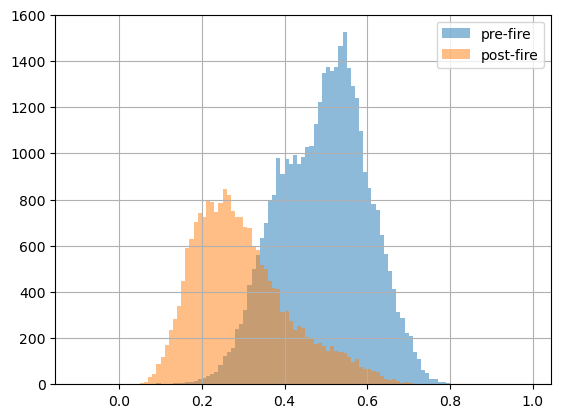

In [160]:
df.pre.hist(
    bins=np.arange(-0.1,1,0.01),
    label='pre-fire',
    alpha=.5
)
df.post.hist(
    bins=np.arange(-0.1,1,0.01),
    label='post-fire',
    alpha=.5
)
plt.legend()

<Axes: >

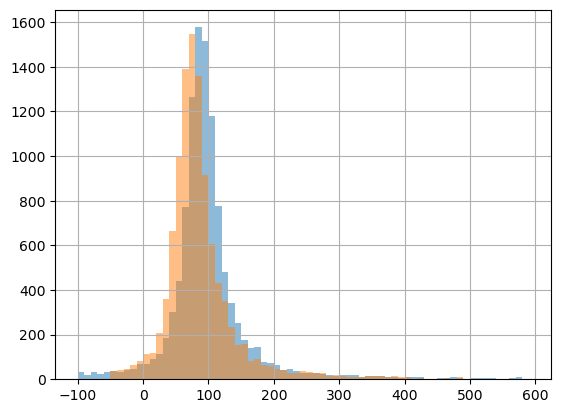

In [161]:
df.perc_recovery_5yr.hist(bins=np.arange(-100, 600, 10), alpha=.5)
df.perc_recovery_2yr.hist(bins=np.arange(-50, 500, 10), alpha=.5)

In [78]:
df_clean = df.dropna()

In [178]:
df_clean['abs_recovery_2yr'] = df_clean[2017]  - df_clean.post
df_clean['abs_recovery_5yr'] = df_clean[2020] - df_clean.post

<Axes: >

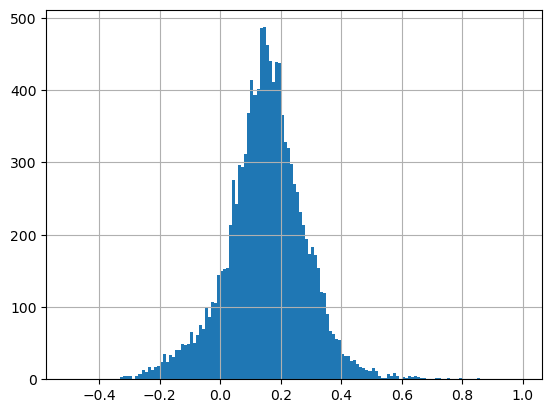

In [135]:
df_clean.abs_recovery_2yr.hist(bins=np.arange(-0.5,1,0.01))

<Axes: >

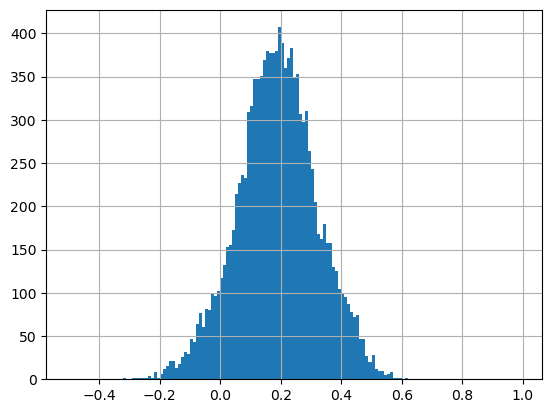

In [136]:
df_clean.abs_recovery_5yr.hist(bins=np.arange(-0.5,1,0.01))

In [185]:
import seaborn as sns

In [186]:
df_clean = df.dropna()

df_clean

y          x         
 2.141359  117.642247    0.678237
           117.644493    0.615995
 2.139113  117.642247    0.666221
           117.644493    0.564701
 2.136867  117.642247    0.619771
                           ...   
-4.016592  114.942809    0.344332
-4.018838  114.942809    0.308602
-4.021084  114.942809    0.309771
-4.025575  114.949547    0.470987
           114.951792    0.482491
Name: 2020, Length: 12307, dtype: float64

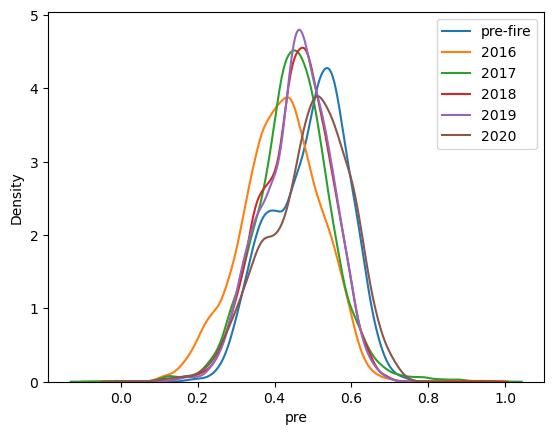

In [200]:
sns.kdeplot(x='pre', 
            data=df_clean,
            label='pre-fire'
           )

for y in range(2016,2021,1):
    sns.kdeplot(df_clean[y][(df_clean[y] > -0.1) & (df_clean[y] < 1)],
                 label=y)
    # plt.show()

plt.legend()
plt.show()

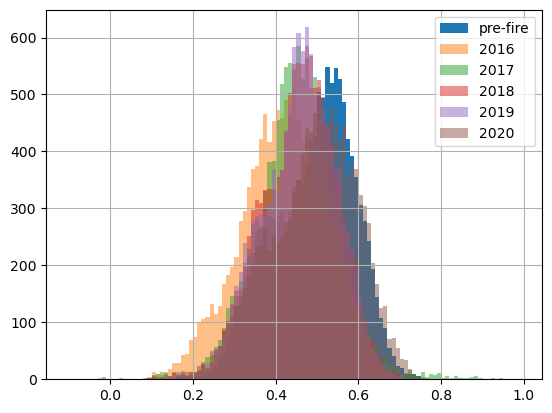

In [184]:
df.dropna()['pre'].hist(bins=np.arange(-0.1, 1, 0.01), label='pre-fire')

for y in range(2016,2021,1):
    df.dropna()[y].hist(bins=np.arange(-0.1, 1, 0.01), label=y, alpha=.5)
plt.legend()
plt.show()

## Raster layers

In [162]:
# make new rasters
pre_fire = rxr.open_rasterio('output-data/predictor-layers/evi_2year_pre.tif')
post_fire = rxr.open_rasterio('output-data/predictor-layers/post_fire_evi.tif')
evi_2017 = rxr.open_rasterio('output-data/EVI/reprojected_EVI_2017.tif')
evi_2020 = rxr.open_rasterio('output-data/EVI/reprojected_EVI_2020.tif')

In [163]:
# relative recovery metric (%)
perc_recovery_2017 = ((evi_2017 - post_fire) / (pre_fire - post_fire)) * 100
perc_recovery_2020 = ((evi_2020 - post_fire) / (pre_fire - post_fire)) * 100

In [131]:
# clean data (remove illogical values)
# perc_recovery_2017 = xr.where((perc_recovery_2017 > 200) | (perc_recovery_2017 < 0), np.nan, perc_recovery_2017).rio.write_crs(4326)
# perc_recovery_2020 = xr.where((perc_recovery_2020 > 200) | (perc_recovery_2020 < 0), np.nan, perc_recovery_2020).rio.write_crs(4326)

In [164]:
# export
perc_recovery_2017.rio.to_raster('output-data/EVI/perc_recovery_2017.tif')
perc_recovery_2020.rio.to_raster('output-data/EVI/perc_recovery_2020.tif')

In [165]:
# absolute recovery
abs_recovery_2017 = evi_2017 - post_fire
abs_recovery_2020 = evi_2020 - post_fire

In [107]:
# clean data (remove illogical values)
# abs_recovery_2017 = xr.where((abs_recovery_2017 > 1) | (abs_recovery_2017 < 0), np.nan, abs_recovery_2017).rio.write_crs(4326)
# abs_recovery_2020 = xr.where((abs_recovery_2020 > 1) | (abs_recovery_2020 < 0), np.nan, abs_recovery_2020).rio.write_crs(4326)

In [166]:
# export
abs_recovery_2017.rio.to_raster('output-data/EVI/abs_recovery_2017.tif')
abs_recovery_2020.rio.to_raster('output-data/EVI/abs_recovery_2020.tif')

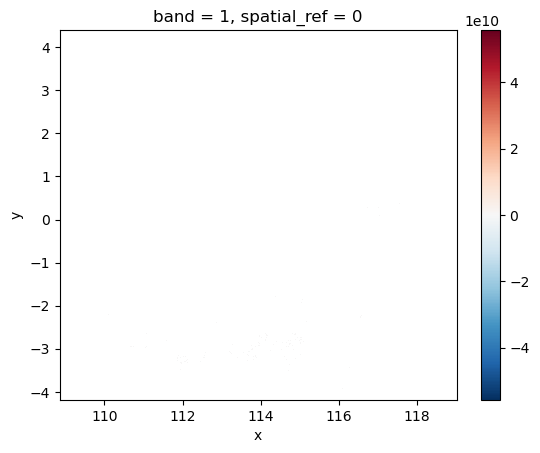

In [142]:
abs_recovery_2017.plot()